# 🎬 Netflix Data Analysis using Python
### Tools: Pandas | Matplotlib | Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [3]:
df = pd.read_csv("/content/netflix_titles.csv.zip")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [5]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

df.dropna(subset=['rating', 'date_added'], inplace=True)

/tmp/ipykernel_5619/2638046052.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_5619/2638046052.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

## Movies vs TV Shows Distribution

This analysis compares the number of Movies and TV Shows available on Netflix.

The visualization helps us understand which type of content dominates the platform.

📌 Insight:
Movies are significantly higher in number compared to TV Shows, indicating Netflix focuses more on movie content.

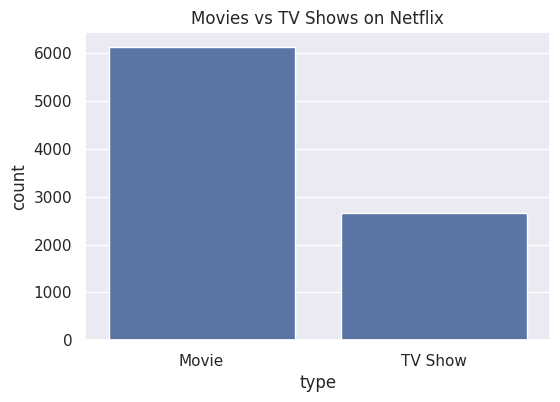

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

## Top 10 Content Producing Countries

This graph shows the top countries contributing the most content on Netflix.

It helps identify which regions are most active in producing movies and TV shows.

📌 Insight:
The United States dominates content production, followed by countries like India and the UK.

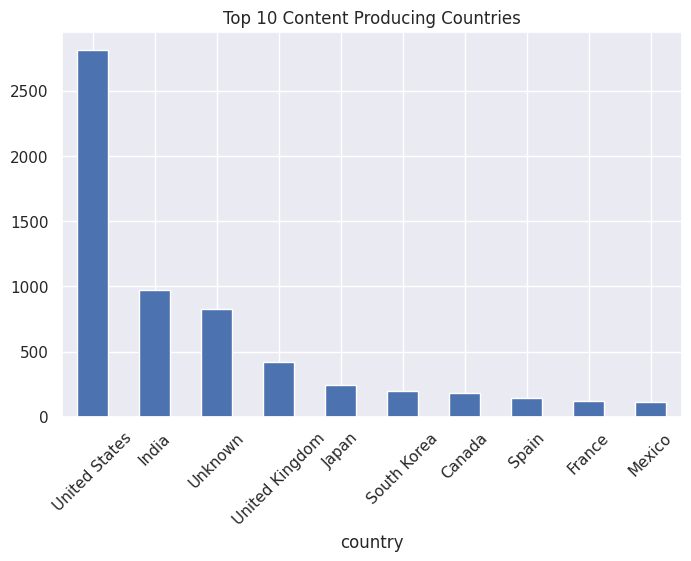

In [7]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xticks(rotation=45)
plt.show()

## Most Popular Genres on Netflix

This analysis identifies the most common genres available on Netflix.

It helps understand audience preferences and content strategy.

📌 Insight:
Drama, International Movies, and Comedies are among the most popular genres on the platform.

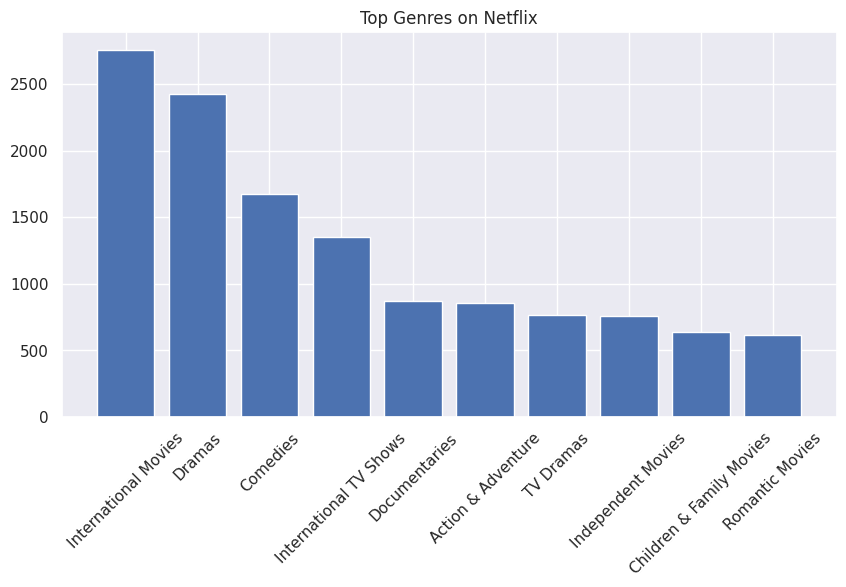

In [10]:
from collections import Counter

genres = df['listed_in'].str.split(', ')
all_genres = sum(genres, [])

genre_count = Counter(all_genres)
top_genres = dict(genre_count.most_common(10))

plt.figure(figsize=(10,5))
plt.bar(top_genres.keys(), top_genres.values())
plt.xticks(rotation=45)
plt.title("Top Genres on Netflix")
plt.show()

In [12]:
print("Insights:")
print("1. Movies dominate Netflix content.")
print("2. USA is the top content producer.")
print("3. Drama and International genres are most popular.")

Insights:
1. Movies dominate Netflix content.
2. USA is the top content producer.
3. Drama and International genres are most popular.


##  Final Insights Summary

From this analysis, we can conclude:

• Netflix has more Movies than TV Shows  
• USA is the leading content producer  
• Drama and International genres dominate  

This project demonstrates data cleaning, analysis, and visualization skills using Python.

In [13]:
# ML Model: Predict Movie vs TV Show

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Prepare data
df_ml = df.copy()
df_ml = df_ml[['type', 'release_year']].dropna()

# Encode target
le = LabelEncoder()
df_ml['type'] = le.fit_transform(df_ml['type'])

X = df_ml[['release_year']]
y = df_ml['type']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.694144400227402
